# Meditation Recognition Model

## Imports

In [ ]:
# Imports
import os

from pathlib import Path
import csv

import numpy as np
import pandas as pd
import mne
import librosa
from statistics import mean, stdev
from scipy.fft import fft

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
from sklearn.ensemble import RandomForestClassifier, VotingClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
import matplotlib.pyplot as plt

True
NVIDIA GeForce RTX 4060 Laptop GPU


## Load the dataset

### We are using the EEG Meditation Dataset from OpenNeuro

In [ ]:
DATA_ROOT = Path("dataset/ds001787")

def parse_forms_file() -> pd.DataFrame:
    df = None

    return df

eeg_df = None
eeg_df.head()

,line_id,form_id,line_num,stroke_path,transcript_path,text,text_len,writer_id,input_type
0,a01-000u-01,a01-000u,1,datasets\lineStrokes-all\lineStrokes\a01\a01-0...,datasets\ascii-all\ascii\a01\a01-000\a01-000u.txt,A MOVE to stop Mr . Gaitskell,29,10011,0.0
1,a01-000u-02,a01-000u,2,datasets\lineStrokes-all\lineStrokes\a01\a01-0...,datasets\ascii-all\ascii\a01\a01-000\a01-000u.txt,from nomnating any more Labour,30,10011,0.0
2,a01-000u-03,a01-000u,3,datasets\lineStrokes-all\lineStrokes\a01\a01-0...,datasets\ascii-all\ascii\a01\a01-000\a01-000u.txt,life Peers is to be made at a,29,10011,0.0
3,a01-000u-04,a01-000u,4,datasets\lineStrokes-all\lineStrokes\a01\a01-0...,datasets\ascii-all\ascii\a01\a01-000\a01-000u.txt,meeting of Labour M Ps tomorrow,31,10011,0.0
4,a01-000u-05,a01-000u,5,datasets\lineStrokes-all\lineStrokes\a01\a01-0...,datasets\ascii-all\ascii\a01\a01-000\a01-000u.txt,Mr . Michael Foot has put down a,32,10011,0.0


## Data preprocessing

Total lines: 12,187
Train/Val: 10,871 / 1,316
Charset size: 82


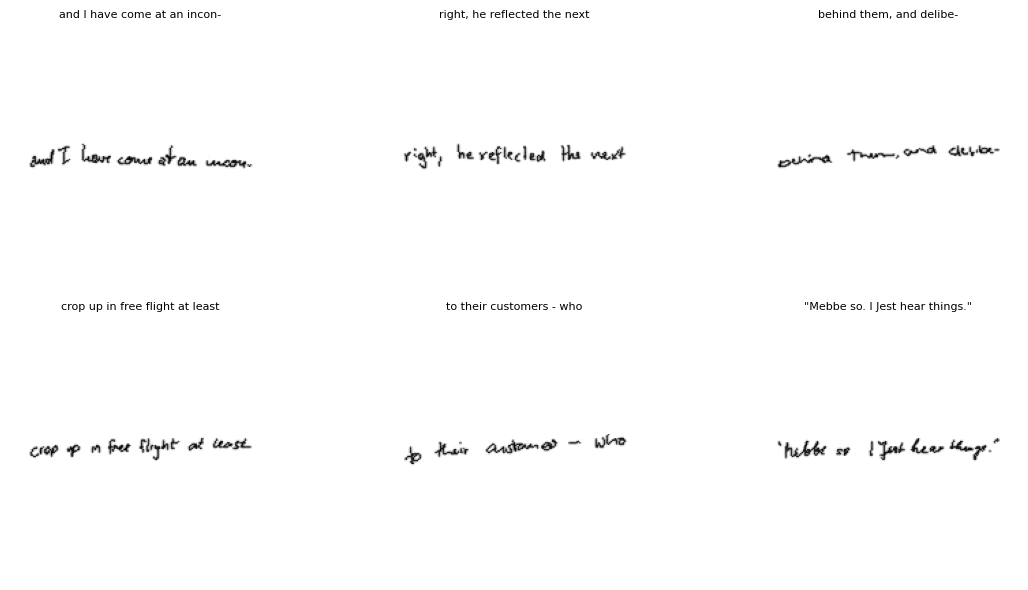

In [ ]:
# Preprocessing: convert variable-size stroke XML into fixed-size grayscale images.
# IMG_SIZE = (96, 96)  # Good default for MobileNetV3/ResNet-18
IMG_SIZE = (96*2, 96*2) # Can we get away with this?
DRAW_THICKNESS = 1

def stroke_xml_to_image(
    stroke_xml_path: str | Path,
    img_size: tuple[int, int] = IMG_SIZE,
    thickness: int = DRAW_THICKNESS
    ) -> np.ndarray:
    root = ET.parse(stroke_xml_path).getroot()
    points = []
    strokes = []

    for stroke in root.findall(".//Stroke"):
        stroke_points = []
        for p in stroke.findall("Point"):
            x = float(p.attrib["x"])
            y = float(p.attrib["y"])
            stroke_points.append((x, y))
            points.append((x, y))
        if len(stroke_points) >= 2:
            strokes.append(stroke_points)

    if not points:
        return np.zeros(img_size, dtype=np.uint8)

    pts = np.array(points, dtype=np.float32)
    min_xy = pts.min(axis=0)
    max_xy = pts.max(axis=0)
    span = np.maximum(max_xy - min_xy, 1e-6)

    h, w = img_size
    pad = 0.08
    scale = min((1 - 2 * pad) * (w - 1) / span[0], (1 - 2 * pad) * (h - 1) / span[1])
    offset_x = ((w - 1) - span[0] * scale) / 2.0
    offset_y = ((h - 1) - span[1] * scale) / 2.0

    canvas = np.full(shape=(h, w), fill_value=255, dtype=np.uint8)
    for stroke in strokes:
        norm = [
            (
                int(round((x - min_xy[0]) * scale + offset_x)),
                int(round((y - min_xy[1]) * scale + offset_y)),
            )
            for x, y in stroke
        ]
        for i in range(1, len(norm)):
            cv2.line(canvas, norm[i - 1], norm[i], color=0, thickness=thickness, lineType=cv2.LINE_AA)

    # Optional denoising and contrast stabilization for webcam-like domain shifts.
    # return cv2.GaussianBlur(canvas, (3, 3), 0)
    return canvas

# Group split by writer_id to reduce writer leakage between train/validation.
gss = GroupShuffleSplit(n_splits=1, train_size=0.9, random_state=42)
groups = line_df["writer_id"].fillna("unknown")
train_idx, val_idx = next(gss.split(line_df, groups=groups))
train_df = line_df.iloc[train_idx].reset_index(drop=True)
val_df = line_df.iloc[val_idx].reset_index(drop=True)

print(f"Total lines: {len(line_df):,}")
print(f"Train/Val: {len(train_df):,} / {len(val_df):,}")

# Build a simple vocabulary for CTC-style OCR targets.
charset = sorted(set("".join(line_df["text"].astype(str).tolist())))
char_to_idx = {ch: i + 1 for i, ch in enumerate(charset)}  # reserve 0 for CTC blank/pad
idx_to_char = {i: ch for ch, i in char_to_idx.items()}
print(f"Charset size: {len(charset)}")

# Quick sanity-check visualization from a random training subset.
sample_n = 6
sample_df = train_df.sample(n=min(sample_n, len(train_df)), random_state=0).reset_index(drop=True)
fig, axes = plt.subplots(2, 3, figsize=(12, 6))
for ax, (_, row) in zip(axes.flat, sample_df.iterrows()):
    img = stroke_xml_to_image(row["stroke_path"], img_size=IMG_SIZE)
    ax.imshow(img, cmap="gray")
    ax.set_title(row["text"][:50], fontsize=8)
    ax.axis("off")
plt.tight_layout()

In [ ]:
class EEGMeditationDataset(Dataset):
    foo = None

In [ ]:
# Entire dataset object (all participants).
all_dataset = None

Participants found: 217
First 10 participant IDs: ['10000', '10002', '10004', '10005', '10006', '10007', '10008', '10009', '10010', '10011']
LOPO participant: 10000
Train samples: 12,179 | Test samples: 8
images: (32, 3, 192, 192)
targets: (907,)
target_lengths: (32,)


## Model Creation

In [ ]:
# Train and evaluate
classifiers = {
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42),
    'SVM': SVC(kernel='rbf', random_state=42),
    'KNN': KNeighborsClassifier(n_neighbors=3)
}

Downloading: "https://download.pytorch.org/models/mobilenet_v3_small-047dcff4.pth" to C:\Users\aidan/.cache\torch\hub\checkpoints\mobilenet_v3_small-047dcff4.pth


100%|██████████| 9.83M/9.83M [00:00<00:00, 63.5MB/s]


MobileNetV3CTC(
  (features): Sequential(
    (0): Conv2dNormActivation(
      (0): Conv2d(3, 16, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
      (1): BatchNorm2d(16, eps=0.001, momentum=0.01, affine=True, track_running_stats=True)
      (2): Hardswish()
    )
    (1): InvertedResidual(
      (block): Sequential(
        (0): Conv2dNormActivation(
          (0): Conv2d(16, 16, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), groups=16, bias=False)
          (1): BatchNorm2d(16, eps=0.001, momentum=0.01, affine=True, track_running_stats=True)
          (2): ReLU(inplace=True)
        )
        (1): SqueezeExcitation(
          (avgpool): AdaptiveAvgPool2d(output_size=1)
          (fc1): Conv2d(16, 8, kernel_size=(1, 1), stride=(1, 1))
          (fc2): Conv2d(8, 16, kernel_size=(1, 1), stride=(1, 1))
          (activation): ReLU()
          (scale_activation): Hardsigmoid()
        )
        (2): Conv2dNormActivation(
          (0): Conv2d(16, 16, kernel_size=(1, 1

## Model Training

In [18]:
def _split_concatenated_targets(targets: torch.Tensor, target_lengths: torch.Tensor) -> list[torch.Tensor]:
    lengths = target_lengths.tolist()
    return list(torch.split(targets, lengths))


def _collapse_ctc_sequence(seq_ids: list[int], blank_id: int = 0) -> list[int]:
    out = []
    prev = None
    for idx in seq_ids:
        if idx != blank_id and idx != prev:
            out.append(idx)
        prev = idx
    return out


def greedy_decode(log_probs: torch.Tensor, idx_to_char: dict[int, str], blank_id: int = 0) -> list[str]:
    """log_probs: [T, B, C]"""
    token_ids = log_probs.argmax(dim=2).transpose(0, 1).tolist()  # [B, T]
    preds = []
    for seq in token_ids:
        collapsed = _collapse_ctc_sequence(seq, blank_id=blank_id)
        preds.append("".join(idx_to_char.get(i, "") for i in collapsed))
    return preds


def train_one_epoch_ctc(
    model: nn.Module,
    train_loader: DataLoader,
    optimizer: optim.Optimizer,
    ctc_loss: nn.CTCLoss,
    device: str = "cpu",
    max_batches: int | None = None,
 ) -> float:
    model.train()
    running = 0.0
    used = 0

    for batch_idx, batch in enumerate(train_loader):
        if max_batches is not None and batch_idx >= max_batches:
            break

        images = batch["images"].to(device)
        targets = batch["targets"].to(device)
        target_lengths = batch["target_lengths"].to(device)

        optimizer.zero_grad()
        logits = model(images)
        log_probs = logits.log_softmax(dim=2)
        input_lengths = torch.full(
            (log_probs.shape[1],), log_probs.shape[0], dtype=torch.long, device=device
        )

        # Keep samples where CTC can be computed safely.
        valid_mask = (target_lengths > 0) & (target_lengths < input_lengths)
        if valid_mask.sum().item() == 0:
            continue

        split_targets = _split_concatenated_targets(targets, target_lengths.cpu())
        valid_indices = valid_mask.nonzero(as_tuple=False).squeeze(1).tolist()
        selected_targets = [split_targets[i] for i in valid_indices]
        selected_target_lengths = target_lengths[valid_mask]
        selected_log_probs = log_probs[:, valid_mask, :]
        selected_input_lengths = input_lengths[valid_mask]

        loss = ctc_loss(
            selected_log_probs,
            torch.cat(selected_targets),
            selected_input_lengths,
            selected_target_lengths,
        )
        loss.backward()
        optimizer.step()

        running += float(loss.item())
        used += 1

    return running / max(used, 1)


@torch.no_grad()
def predict_ctc(model: nn.Module, loader: DataLoader, idx_to_char: dict[int, str], device: str = "cpu") -> list[str]:
    model.eval()
    outputs = []
    for batch in loader:
        images = batch["images"].to(device)
        logits = model(images)
        log_probs = logits.log_softmax(dim=2)
        outputs.extend(greedy_decode(log_probs, idx_to_char=idx_to_char, blank_id=0))
    return outputs


def run_ctc_fold_predictor(
    train_loader: DataLoader,
    test_loader: DataLoader,
    test_ds: WhiteboardDrawingDataset,
    participant_id: str,
    epochs: int = 1,
    lr: float = 1e-3,
    device: str | None = None,
    max_train_batches: int | None = 100,
 ) -> list[str]:
    _ = test_ds, participant_id
    if device is None:
        device = "cuda" if torch.cuda.is_available() else "cpu"

    model = make_model(num_classes=len(char_to_idx) + 1).to(device)
    optimizer = optim.AdamW(model.parameters(), lr=lr)
    ctc_loss = nn.CTCLoss(blank=0, reduction="mean", zero_infinity=True)

    for _ in range(epochs):
        train_one_epoch_ctc(
            model=model,
            train_loader=train_loader,
            optimizer=optimizer,
            ctc_loss=ctc_loss,
            device=device,
            max_batches=max_train_batches,
        )

    return predict_ctc(model=model, loader=test_loader, idx_to_char=idx_to_char, device=device)

## Model Evaluation (LOPO)

In [19]:
def levenshtein_distance(a: str, b: str) -> int:
    """Classic dynamic-programming Levenshtein distance."""
    if a == b:
        return 0
    if len(a) == 0:
        return len(b)
    if len(b) == 0:
        return len(a)

    prev = list(range(len(b) + 1))
    for i, ca in enumerate(a, start=1):
        curr = [i] + [0] * len(b)
        for j, cb in enumerate(b, start=1):
            cost = 0 if ca == cb else 1
            curr[j] = min(
                prev[j] + 1,      # deletion
                curr[j - 1] + 1,  # insertion
                prev[j - 1] + cost,
            )
        prev = curr
    return prev[-1]


def compute_cer_wer(references: list[str], predictions: list[str]) -> tuple[float, float]:
    """Returns (CER, WER)."""
    if len(references) != len(predictions):
        raise ValueError("references and predictions must have the same length")

    char_err = 0
    char_total = 0
    word_err = 0
    word_total = 0

    for ref, pred in zip(references, predictions):
        ref = normalize_english_text(ref)
        pred = normalize_english_text(pred)

        char_err += levenshtein_distance(ref, pred)
        char_total += max(len(ref), 1)

        ref_words = ref.split()
        pred_words = pred.split()
        word_err += levenshtein_distance("\n".join(ref_words), "\n".join(pred_words))
        word_total += max(len(ref_words), 1)

    cer = char_err / char_total
    wer = word_err / word_total
    return cer, wer


def evaluate_lopo_ocr(
    data_frame: pd.DataFrame,
    participant_ids: list[str],
    char_to_idx: dict[str, int],
    image_loader,
    fold_predictor_fn,
    max_participants: int | None = None,
    batch_size: int = 32,
    img_size: tuple[int, int] = IMG_SIZE,
    downsample_factor: int | None = 4,
    channels: int = 3,
    keep_empty_targets: bool = True,
    num_workers: int = 0,
 ):
    """Run LOPO CV. fold_predictor_fn must return one predicted string per test sample."""
    selected = participant_ids if max_participants is None else participant_ids[:max_participants]
    fold_rows = []

    for i, participant in enumerate(selected, start=1):
        train_ds, test_ds, train_loader, test_loader = make_lopo_dataloaders(
            data_frame=data_frame,
            test_participant=participant,
            char_to_idx=char_to_idx,
            image_loader=image_loader,
            img_size=img_size,
            batch_size=batch_size,
            channels=channels,
            downsample_factor=downsample_factor,
            keep_empty_targets=keep_empty_targets,
            num_workers=num_workers,
        )

        refs = test_ds.df["clean_text"].tolist()
        preds = fold_predictor_fn(train_loader, test_loader, test_ds, participant)
        if len(preds) != len(refs):
            raise ValueError(
                f"Fold {participant}: predictor returned {len(preds)} predictions for {len(refs)} references"
            )

        cer, wer = compute_cer_wer(refs, preds)
        fold_rows.append({
            "fold": i,
            "participant": participant,
            "n_test": len(refs),
            "CER": cer,
            "WER": wer,
        })
        print(f"[{i:03d}/{len(selected):03d}] participant={participant} n_test={len(refs)} CER={cer:.4f} WER={wer:.4f}")

    result_df = pd.DataFrame(fold_rows)
    print("\nLOPO summary")
    print(f"participants: {len(result_df)}")
    print(f"mean CER: {result_df['CER'].mean():.4f}")
    print(f"mean WER: {result_df['WER'].mean():.4f}")
    return result_df


# Real fold predictor wrapper with lightweight defaults for quick experiments.
def fold_predictor(train_loader, test_loader, test_ds, participant_id):
    return run_ctc_fold_predictor(
        train_loader=train_loader,
        test_loader=test_loader,
        test_ds=test_ds,
        participant_id=participant_id,
        epochs=1,
        lr=1e-3,
        max_train_batches=75,
    )


# Start small; set max_participants=None for full LOPO once training config is stable.
lopo_results = evaluate_lopo_ocr(
    data_frame=line_df,
    participant_ids=participant_ids,
    char_to_idx=char_to_idx,
    image_loader=stroke_xml_to_image,
    fold_predictor_fn=fold_predictor,
    max_participants=3,
    batch_size=32,
    img_size=IMG_SIZE,
    downsample_factor=4,
    channels=3,
    keep_empty_targets=True,
    num_workers=0,
 )

lopo_results.head()

[001/003] participant=10000 n_test=8 CER=1.0000 WER=5.4091
[002/003] participant=10002 n_test=48 CER=1.0000 WER=5.4373
[003/003] participant=10004 n_test=69 CER=0.9928 WER=5.1197

LOPO summary
participants: 3
mean CER: 0.9976
mean WER: 5.3220


,fold,participant,n_test,CER,WER
0,1,10000,8,1.000000,5.409091
1,2,10002,48,1.000000,5.437309
2,3,10004,69,0.992818,5.119658


## Save as state dictionary or ONNX model

In [ ]:
# State dictionary
torch.save(model.state_dict(), 'whiteboard.pth')

# ONNX program
onnx_program = torch.onnx.export(model, example_inputs = None, dynamo=True) # TODO: add an example input
onnx_program.save("whiteboard.onnx")